In [1]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import Callback
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
import matplotlib.pyplot as plt

class EarlyStoppingLossDiff(Callback):
    def __init__(self, patience=1, min_loss_diff=0.01):
        super(EarlyStoppingLossDiff, self).__init__()
        self.patience = patience
        self.min_loss_diff = min_loss_diff
        self.wait = 0
        self.stopped_epoch = 0
        self.previous_loss = None
        
    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get('loss')
        
        if self.previous_loss is not None:
            loss_diff = abs(current_loss - self.previous_loss)
            
            if loss_diff < self.min_loss_diff:
                self.wait += 1
                if self.wait >= self.patience:
                    self.stopped_epoch = epoch
                    self.model.stop_training = True
                    print(f"\nEarly stopping triggered at epoch {epoch + 1} due to small loss difference: {loss_diff:.6f}")
            else:
                self.wait = 0
        
        self.previous_loss = current_loss

def create_model(architecture, input_dim=13):
    """Helper function to create models with different architectures"""
    model = Sequential()
    
    # Add hidden layers based on architecture
    for i, neurons in enumerate(architecture):
        if i == 0:
            # First hidden layer
            model.add(Dense(neurons, activation='relu', input_dim=input_dim))
        else:
            # Subsequent hidden layers
            model.add(Dense(neurons, activation='relu'))
    
    # Output layer
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        optimizer='adam',
        loss='mean_squared_error',
        metrics=['mse']
    )
    
    return model

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return metrics and history"""
    print(f"\n{'='*50}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*50}")
    
    # Create early stopping callback
    early_stopping = EarlyStoppingLossDiff(patience=1, min_loss_diff=0.01)
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=20,
        verbose=1,
        callbacks=[early_stopping]
    )
    
    # Make predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    print(f"\n{model_name} Results:")
    print(f"Training MSE: {train_mse:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Training R²: {train_r2:.4f}")
    print(f"Test R²: {test_r2:.4f}")
    
    return {
        'history': history,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'model_name': model_name
    }

In [2]:
# Load and prepare data
df = pd.read_csv('BostonHousing.csv')
print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
print(df.head())
print('\nDataset info:')
print(df.info())
print('\nStatistical summary:')
print(df.describe())

# Prepare features and target
X = df.iloc[:, 0:13]  # All features (columns 0-12)
y = df.iloc[:, 13]    # Target variable (medv)

print('\nFeatures shape:', X.shape)
print('Target shape:', y.shape)
print('Feature columns:', list(X.columns))

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nTraining set: {X_train_scaled.shape[0]} samples')
print(f'Test set: {X_test_scaled.shape[0]} samples')

Dataset shape: (506, 14)

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 n

In [3]:
print("\n" + "="*80)
print("NEURAL NETWORK ARCHITECTURE ANALYSIS")
print("="*80)
print("\nAnalyzing 4 different model architectures:")
print("1. Low Neurons, Low Depth")
print("2. Low Neurons, High Depth")
print("3. High Neurons, Low Depth")
print("4. High Neurons, High Depth")


NEURAL NETWORK ARCHITECTURE ANALYSIS

Analyzing 4 different model architectures:
1. Low Neurons, Low Depth
2. Low Neurons, High Depth
3. High Neurons, Low Depth
4. High Neurons, High Depth


In [4]:
# Model 1: Low Neurons, Low Depth
# Architecture: 4 neurons, 2 layers
model_1_arch = [4, 4]
model_1 = create_model(model_1_arch)
print(f"\nModel 1 Architecture: {model_1_arch}")
print("Low Neurons (4), Low Depth (2 layers)")
model_1.summary()

# Train and evaluate
results_1 = train_and_evaluate_model(
    model_1, X_train_scaled, y_train, X_test_scaled, y_test, 
    "Low Neurons, Low Depth"
)


Model 1 Architecture: [4, 4]
Low Neurons (4), Low Depth (2 layers)


c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)


TRAINING: Low Neurons, Low Depth
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 628.8312 - mse: 628.8312 - val_loss: 578.9589 - val_mse: 578.9589
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 626.1172 - mse: 626.1172 - val_loss: 576.5291 - val_mse: 576.5291
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 623.8752 - mse: 623.8752 - val_loss: 574.4078 - val_mse: 574.4077
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 621.8756 - mse: 621.8756 - val_loss: 572.6597 - val_mse: 572.6597
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 620.1221 - mse: 620.1221 - val_loss: 570.9627 - val_mse: 570.9627
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 618.3257 - mse: 618.3257 - val_loss: 569.2592 - val_mse: 569.2592
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 616.4725 - mse: 616.4725 - val_loss: 567.4414 - val_mse: 567.4414
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 614.4492 - mse: 614.4492 - val_loss: 56

In [5]:
# Model 2: Low Neurons, High Depth
# Architecture: 4 neurons, 6 layers
model_2_arch = [4, 4, 4, 4, 4, 4]
model_2 = create_model(model_2_arch)
print(f"\nModel 2 Architecture: {model_2_arch}")
print("Low Neurons (4), High Depth (6 layers)")
model_2.summary()

# Train and evaluate
results_2 = train_and_evaluate_model(
    model_2, X_train_scaled, y_train, X_test_scaled, y_test, 
    "Low Neurons, High Depth"
)


Model 2 Architecture: [4, 4, 4, 4, 4, 4]
Low Neurons (4), High Depth (6 layers)


c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)


TRAINING: Low Neurons, High Depth
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 653.7734 - mse: 653.7734 - val_loss: 593.2936 - val_mse: 593.2936
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 638.5396 - mse: 638.5396 - val_loss: 582.4591 - val_mse: 582.4591
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 628.0773 - mse: 628.0773 - val_loss: 573.8632 - val_mse: 573.8632
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 619.5640 - mse: 619.5640 - val_loss: 566.7620 - val_mse: 566.7620
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 612.7781 - mse: 612.7781 - val_loss: 560.8328 - val_mse: 560.8328
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 606.7421 - mse: 606.7421 - val_loss: 554.9492 - val_mse: 554.9492
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 600.4384 - mse: 600.4384 - val_loss: 548.5388 - val_mse: 548.5388
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 593.0247 - mse: 593.0247 - val_loss: 5

In [6]:
# Model 3: High Neurons, Low Depth
# Architecture: 64 neurons, 2 layers
model_3_arch = [64, 64]
model_3 = create_model(model_3_arch)
print(f"\nModel 3 Architecture: {model_3_arch}")
print("High Neurons (64), Low Depth (2 layers)")
model_3.summary()

# Train and evaluate
results_3 = train_and_evaluate_model(
    model_3, X_train_scaled, y_train, X_test_scaled, y_test, 
    "High Neurons, Low Depth"
)


Model 3 Architecture: [64, 64]
High Neurons (64), Low Depth (2 layers)


c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING: High Neurons, Low Depth
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 554.7893 - mse: 554.7893 - val_loss: 467.8751 - val_mse: 467.8751
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 467.4041 - mse: 467.4041 - val_loss: 370.6204 - val_mse: 370.6204
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 348.9034 - mse: 348.9034 - val_loss: 245.7841 - val_mse: 245.7841
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 213.8222 - mse: 213.8222 - val_loss: 127.4627 - val_mse: 127.4627
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 112.4585 - mse: 112.4585 - val_loss: 68.0793 - val_mse: 68.0793
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 71.0701 - mse: 71.0701 - val_loss: 46.7389 - val_mse: 46.7389
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 48.9828 - mse: 48.9828 - val_loss: 34.8210 - val_mse: 34.8210
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.8902 - mse: 33.8902 - val_loss: 30.1484 - val_

In [7]:
# Model 4: High Neurons, High Depth
# Architecture: 64 neurons, 6 layers
model_4_arch = [64, 64, 64, 64, 64, 64]
model_4 = create_model(model_4_arch)
print(f"\nModel 4 Architecture: {model_4_arch}")
print("High Neurons (64), High Depth (6 layers)")
model_4.summary()

# Train and evaluate
results_4 = train_and_evaluate_model(
    model_4, X_train_scaled, y_train, X_test_scaled, y_test, 
    "High Neurons, High Depth"
)


Model 4 Architecture: [64, 64, 64, 64, 64, 64]
High Neurons (64), High Depth (6 layers)


c:\Users\manis\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,761 (85.00 KB)

 Trainable params: 21,761 (85.00 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING: High Neurons, High Depth
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 575.8036 - mse: 575.8036 - val_loss: 424.9340 - val_mse: 424.9340
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 282.6297 - mse: 282.6297 - val_loss: 56.7004 - val_mse: 56.7004
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63.7520 - mse: 63.7520 - val_loss: 38.3197 - val_mse: 38.3197
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35.3790 - mse: 35.3790 - val_loss: 32.1316 - val_mse: 32.1316
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.6738 - mse: 26.6738 - val_loss: 26.7427 - val_mse: 26.7427
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.7831 - mse: 20.7831 - val_loss: 23.2444 - val_mse: 23.2444
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 17.6127 - mse: 17.6127 - val_loss: 20.9700 - val_mse: 20.9700
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.6355 - mse: 15.6355 - val_loss: 20.1316 - val_mse: 20.13

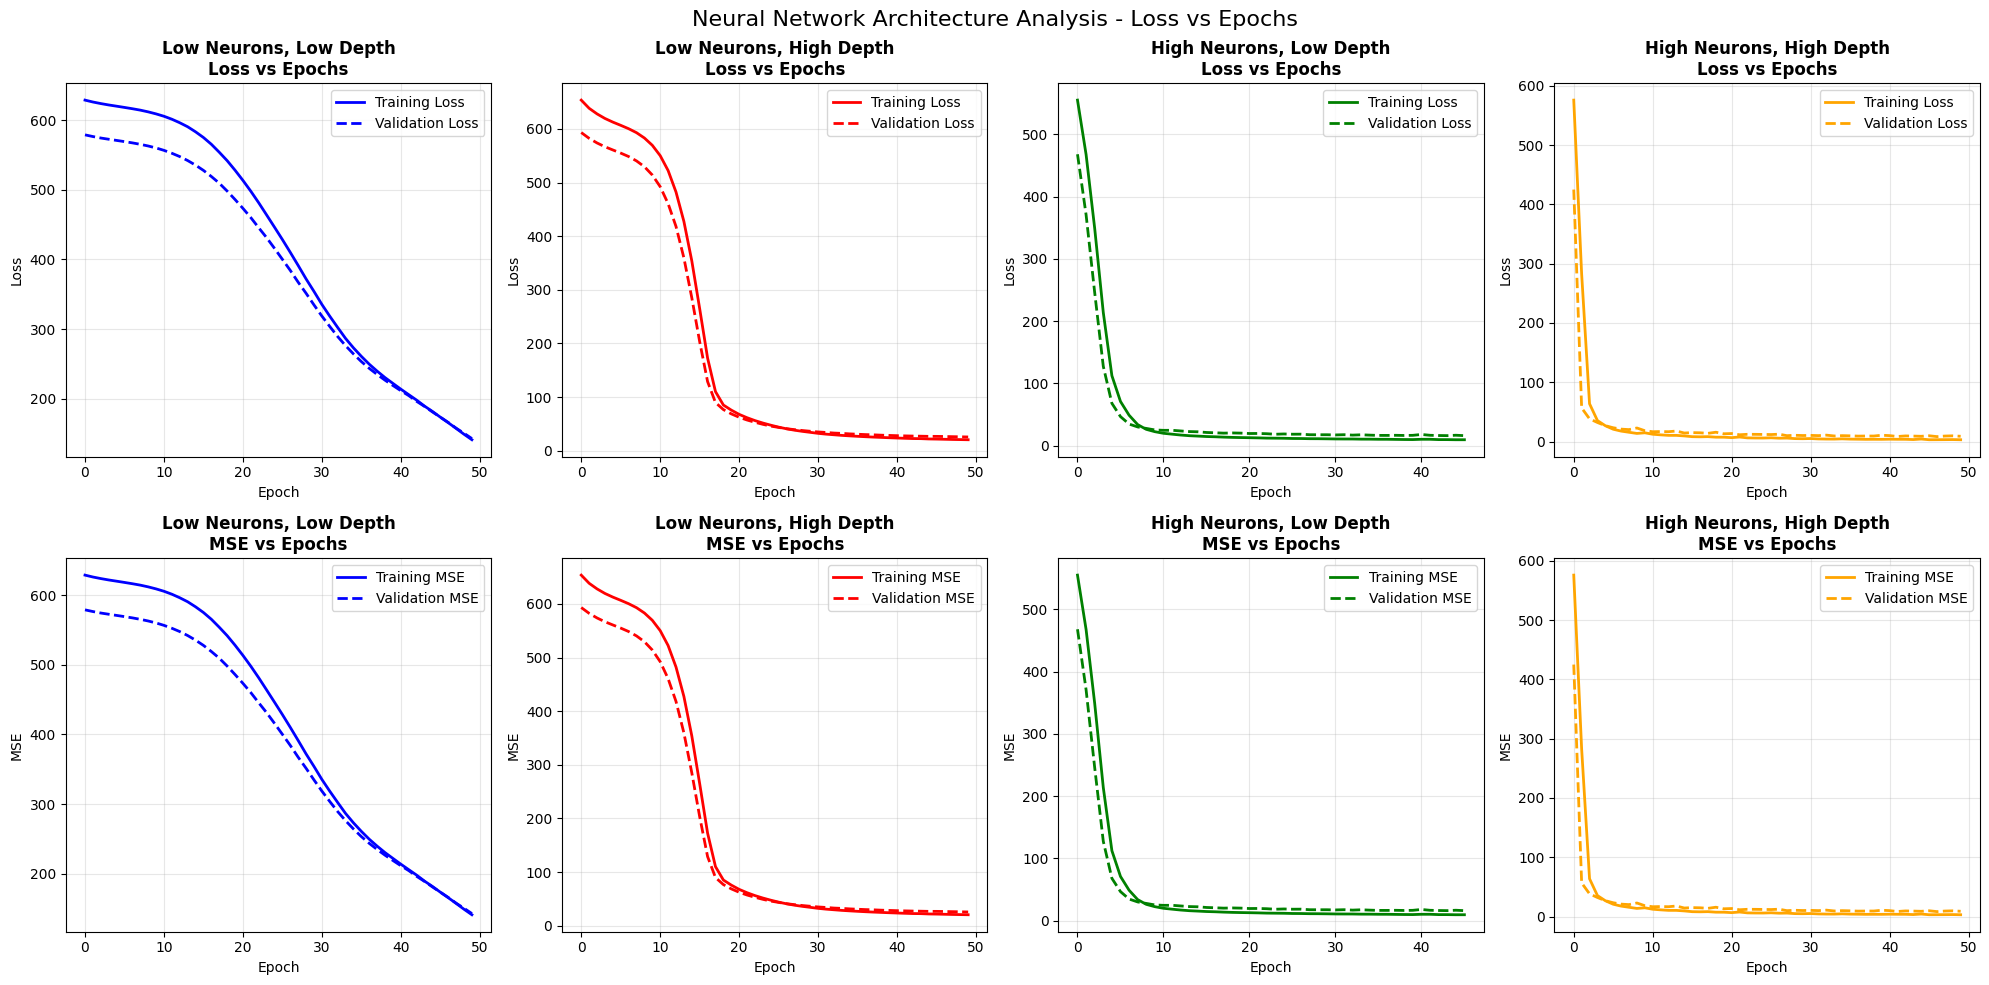

In [8]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Neural Network Architecture Analysis - Loss vs Epochs', fontsize=16)

all_results = [results_1, results_2, results_3, results_4]
colors = ['blue', 'red', 'green', 'orange']

for i, (result, color) in enumerate(zip(all_results, colors)):
    history = result['history']
    model_name = result['model_name']
    
    # Plot training and validation loss
    ax1 = axes[0, i]
    ax1.plot(history.history['loss'], color=color, label='Training Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], color=color, linestyle='--', label='Validation Loss', linewidth=2)
    ax1.set_title(f'{model_name}\nLoss vs Epochs', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot training and validation MSE
    ax2 = axes[1, i]
    ax2.plot(history.history['mse'], color=color, label='Training MSE', linewidth=2)
    ax2.plot(history.history['val_mse'], color=color, linestyle='--', label='Validation MSE', linewidth=2)
    ax2.set_title(f'{model_name}\nMSE vs Epochs', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('MSE')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

C:\Users\manis\AppData\Local\Temp\ipykernel_16092\3068229076.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(model_names, rotation=45, ha='right')


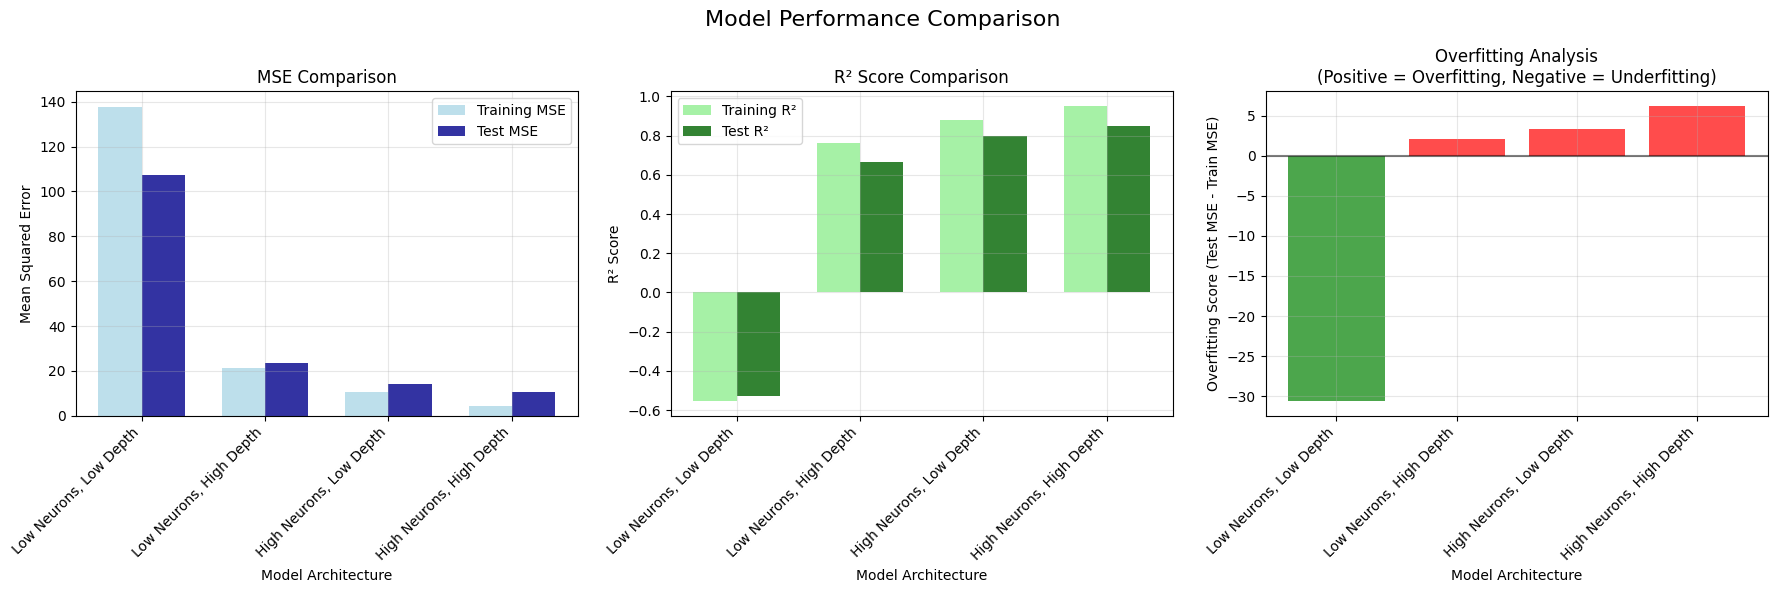

In [9]:
# Create performance comparison charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison', fontsize=16)

# Extract data for plotting
model_names = [result['model_name'] for result in all_results]
train_mses = [result['train_mse'] for result in all_results]
test_mses = [result['test_mse'] for result in all_results]
train_r2s = [result['train_r2'] for result in all_results]
test_r2s = [result['test_r2'] for result in all_results]

# MSE Comparison
ax1 = axes[0]
x = range(len(model_names))
width = 0.35
ax1.bar([i - width/2 for i in x], train_mses, width, label='Training MSE', alpha=0.8, color='lightblue')
ax1.bar([i + width/2 for i in x], test_mses, width, label='Test MSE', alpha=0.8, color='darkblue')
ax1.set_xlabel('Model Architecture')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('MSE Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# R² Comparison
ax2 = axes[1]
ax2.bar([i - width/2 for i in x], train_r2s, width, label='Training R²', alpha=0.8, color='lightgreen')
ax2.bar([i + width/2 for i in x], test_r2s, width, label='Test R²', alpha=0.8, color='darkgreen')
ax2.set_xlabel('Model Architecture')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Overfitting Analysis (Test MSE - Train MSE)
ax3 = axes[2]
overfitting_scores = [test_mse - train_mse for test_mse, train_mse in zip(test_mses, train_mses)]
colors_overfit = ['red' if score > 0 else 'green' for score in overfitting_scores]
ax3.bar(model_names, overfitting_scores, color=colors_overfit, alpha=0.7)
ax3.set_xlabel('Model Architecture')
ax3.set_ylabel('Overfitting Score (Test MSE - Train MSE)')
ax3.set_title('Overfitting Analysis\n(Positive = Overfitting, Negative = Underfitting)')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax3.set_xticklabels(model_names, rotation=45, ha='right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Final Analysis Summary
print("\n" + "="*80)
print("ANALYSIS SUMMARY")
print("="*80)

print("\n📊 MODEL PERFORMANCE COMPARISON:")
print("-"*50)

for i, result in enumerate(all_results, 1):
    print(f"\nModel {i}: {result['model_name']}")
    print(f"  📈 Training MSE: {result['train_mse']:.4f}")
    print(f"  📈 Test MSE: {result['test_mse']:.4f}")
    print(f"  📊 Training R²: {result['train_r2']:.4f}")
    print(f"  📊 Test R²: {result['test_r2']:.4f}")
    
    # Calculate overfitting
    overfitting = result['test_mse'] - result['train_mse']
    if overfitting > 0:
        print(f"  ⚠️  Overfitting detected: {overfitting:.4f}")
    else:
        print(f"  ✅ Good generalization")

print("\n\n🔍 KEY INSIGHTS:")
print("-"*50)

# Find best models
best_test_mse_idx = np.argmin(test_mses)
best_test_r2_idx = np.argmax(test_r2s)

print(f"🏆 Best Test Performance: {all_results[best_test_mse_idx]['model_name']}")
print(f"   Test MSE: {test_mses[best_test_mse_idx]:.4f}")
print(f"   Test R²: {test_r2s[best_test_mse_idx]:.4f}")

print(f"\n🏆 Best R² Score: {all_results[best_test_r2_idx]['model_name']}")
print(f"   Test R²: {test_r2s[best_test_r2_idx]:.4f}")
print(f"   Test MSE: {test_mses[best_test_r2_idx]:.4f}")

# Analyze depth vs width
low_depth_models = [results_1, results_3]  # Models 1 and 3
high_depth_models = [results_2, results_4]  # Models 2 and 4
low_width_models = [results_1, results_2]  # Models 1 and 2
high_width_models = [results_3, results_4]  # Models 3 and 4

avg_low_depth_mse = np.mean([m['test_mse'] for m in low_depth_models])
avg_high_depth_mse = np.mean([m['test_mse'] for m in high_depth_models])
avg_low_width_mse = np.mean([m['test_mse'] for m in low_width_models])
avg_high_width_mse = np.mean([m['test_mse'] for m in high_width_models])

print("\n📈 ARCHITECTURE IMPACT ANALYSIS:")
print("-"*50)
print(f"Average Test MSE - Low Depth Models: {avg_low_depth_mse:.4f}")
print(f"Average Test MSE - High Depth Models: {avg_high_depth_mse:.4f}")
if avg_high_depth_mse < avg_low_depth_mse:
    print("✅ Higher depth generally improves performance")
else:
    print("⚠️  Higher depth may lead to overfitting")

print(f"\nAverage Test MSE - Low Width Models: {avg_low_width_mse:.4f}")
print(f"Average Test MSE - High Width Models: {avg_high_width_mse:.4f}")
if avg_high_width_mse < avg_low_width_mse:
    print("✅ Higher width generally improves performance")
else:
    print("⚠️  Higher width may lead to overfitting")

print("\n💡 RECOMMENDATIONS:")
print("-"*50)
print("1. Start with moderate depth and width")
print("2. Monitor for overfitting (large gap between train/test metrics)")
print("3. Use early stopping to prevent overfitting")
print("4. Consider regularization techniques for complex models")
print("5. Cross-validation can help find optimal architecture")


ANALYSIS SUMMARY

📊 MODEL PERFORMANCE COMPARISON:
--------------------------------------------------

Model 1: Low Neurons, Low Depth
  📈 Training MSE: 137.7902
  📈 Test MSE: 107.1914
  📊 Training R²: -0.5538
  📊 Test R²: -0.5307
  ✅ Good generalization

Model 2: Low Neurons, High Depth
  📈 Training MSE: 21.2177
  📈 Test MSE: 23.2904
  📊 Training R²: 0.7607
  📊 Test R²: 0.6674
  ⚠️  Overfitting detected: 2.0727

Model 3: High Neurons, Low Depth
  📈 Training MSE: 10.6882
  📈 Test MSE: 14.0756
  📊 Training R²: 0.8795
  📊 Test R²: 0.7990
  ⚠️  Overfitting detected: 3.3874

Model 4: High Neurons, High Depth
  📈 Training MSE: 4.2659
  📈 Test MSE: 10.4835
  📊 Training R²: 0.9519
  📊 Test R²: 0.8503
  ⚠️  Overfitting detected: 6.2175


🔍 KEY INSIGHTS:
--------------------------------------------------
🏆 Best Test Performance: High Neurons, High Depth
   Test MSE: 10.4835
   Test R²: 0.8503

🏆 Best R² Score: High Neurons, High Depth
   Test R²: 0.8503
   Test MSE: 10.4835

📈 ARCHITECTURE IMPA